In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW

import matplotlib.pyplot as plt

In [4]:
#Starobinsky potential
V = '3*M**2/4*(1 - exp(-sqrt(2/3)*phi) )**2*(1 + b/(1 + ((phi-phi_0)/c)**2))'
param = {'M' : 1.3e-5, 'b': 0.0004, 'phi_0': 5.1, 'c': 0.00999311}
potential = PotentialFunction.function(V, param_values=param) #Instancia de la clase Potential para el modelo R^2

#Creando instancia de la clase Background. Resuelve automáticamente el sistema dada la condición inicial del inflatón
background = Background(potential, phi0 = 5.6)
sol = background.solver()   

In [5]:
#Extrayendo datos de la clase background
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend


Saved to ./Data/background.dat


np.float64(76.7076707670767)

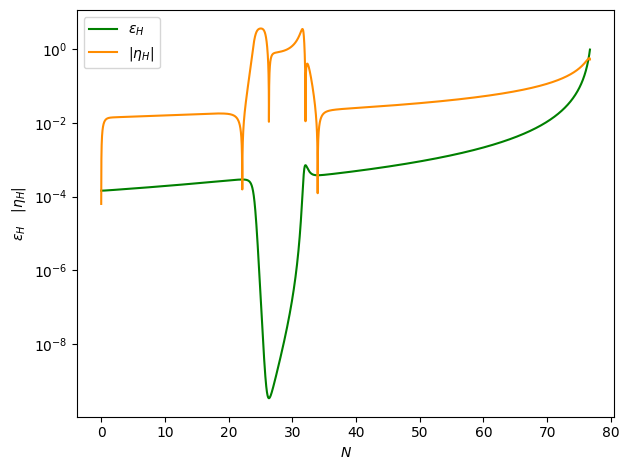

In [6]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 'best')
#plt.title('Slow-roll parameters')
plt.tight_layout()
plt.show()

In [12]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
sol_pivot = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.187170633908469e-09
Tensor to scalar ratio at pivot scale is 0.0038099247604697576


In [13]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:21<00:00, 46.28it/s]


$Ps_peak = 2.3501\times 10^{-02}$
$k_peak = 3.1811\times 10^{+02}\,\mathrm{Mpc}^-1$
Saved to ./Data/power_spectra.dat


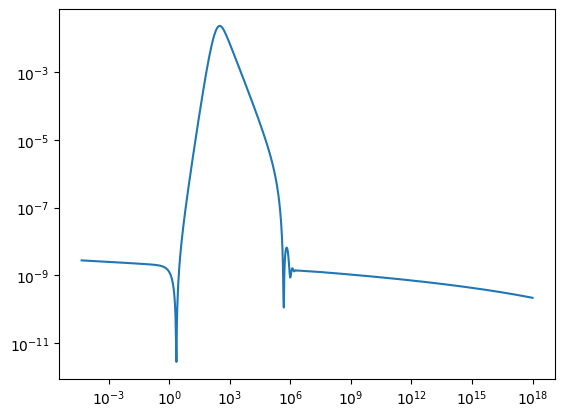

In [14]:
plt.loglog(pert.k_modes, PS[0])


In [15]:
pert.spectral_tilts

{'n_s': 0.9618504241913495, 'n_t': -0.0004935868194838393}

In [16]:
pbh = PBHAbundance(perturbations=pert, delta_c=0.4, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH()
pbh.save_pbh(path='./Data')

fPBH_peak = 2.0264241758952817e-15
MPBH_peak = 37403858.83332525 M⊙
Saved to ./Data/pbh_abundance.dat


Computing SIGW for 1000 modes...
Omega_GW_peak = 4.788225197722658e-09
f_peak = 1.3135954569803175e-13 Hz


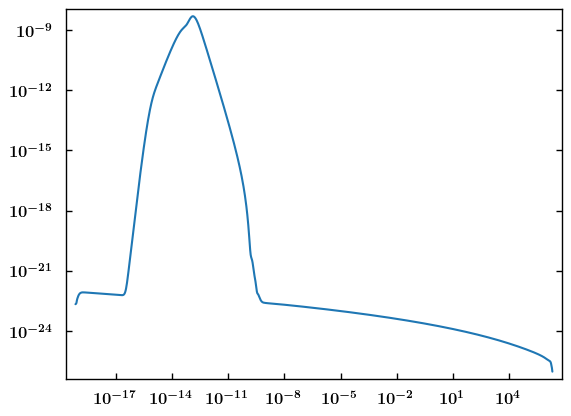

In [10]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 500, save=True)
plt.loglog(f, omega)